# IC3392: Compare v3_v0.6 vs v3tk_v7.6.8

This notebook compares two ngist runs of IC3392:

- `v3_v0.6` (4800-7000, older ngist)
- `v3tk_v7.6.8` (4800-9100, current ngist)

Focus:

1. Spatial binning
2. Stellar kinematics
3. SFH-derived maps (age, metallicity, and E(B-V) where available)

The workflow first inspects FITS structures, then auto-extracts matching maps and visualizes old/new/difference.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits

plt.style.use('seaborn-v0_8-whitegrid')

root = Path('.')
old_dir = root / 'IC3392_v3_v0.6'
new_dir = root / 'IC3392_v3tk_v7.6.8'

files = {
    'old': {
        'spatial': old_dir / 'IC3392_SPATIAL_BINNING_maps.fits',
        'kin': old_dir / 'IC3392_KIN_maps.fits',
        'sfh': old_dir / 'IC3392_SFH_maps.fits',
    },
    'new': {
        'spatial': new_dir / 'IC3392_v3tk_v7.6.8_spatial_binning_maps.fits',
        'kin': new_dir / 'IC3392_v3tk_v7.6.8_kin_maps.fits',
        'sfh': new_dir / 'IC3392_v3tk_v7.6.8_sfh_maps.fits',
    }
}

for tag in ('old', 'new'):
    for kind, p in files[tag].items():
        if not p.exists():
            raise FileNotFoundError(f'Missing {tag}/{kind}: {p}')

print('All target files found.')
for tag in ('old', 'new'):
    print(f'\n{tag.upper()}')
    for kind, p in files[tag].items():
        print(f'  {kind:7s}: {p}')

All target files found.

OLD
  spatial: IC3392_v3_v0.6/IC3392_SPATIAL_BINNING_maps.fits
  kin    : IC3392_v3_v0.6/IC3392_KIN_maps.fits
  sfh    : IC3392_v3_v0.6/IC3392_SFH_maps.fits

NEW
  spatial: IC3392_v3tk_v7.6.8/IC3392_v3tk_v7.6.8_spatial_binning_maps.fits
  kin    : IC3392_v3tk_v7.6.8/IC3392_v3tk_v7.6.8_kin_maps.fits
  sfh    : IC3392_v3tk_v7.6.8/IC3392_v3tk_v7.6.8_sfh_maps.fits


In [2]:
def summarize_hdus(path):
    rows = []
    with fits.open(path) as hdul:
        for i, hdu in enumerate(hdul):
            data = hdu.data
            shape = None if data is None else tuple(data.shape)
            dtype = None if data is None else str(data.dtype)
            rows.append(
                {
                    'idx': i,
                    'extname': hdu.name,
                    'type': type(hdu).__name__,
                    'shape': shape,
                    'dtype': dtype,
                }
            )
    return pd.DataFrame(rows)

for run in ('old', 'new'):
    for kind in ('spatial', 'kin', 'sfh'):
        p = files[run][kind]
        print(f'\n===== {run.upper()} :: {kind.upper()} :: {p.name} =====')
        display(summarize_hdus(p))


===== OLD :: SPATIAL :: IC3392_SPATIAL_BINNING_maps.fits =====


,idx,extname,type,shape,dtype
0,0,PRIMARY,PrimaryHDU,None,None
1,1,BINID,ImageHDU,"(438, 437)",>f8
2,2,FLUX,ImageHDU,"(438, 437)",>f8
3,3,SNR,ImageHDU,"(438, 437)",>f8
4,4,SNRBIN,ImageHDU,"(438, 437)",>f8
5,5,XBIN,ImageHDU,"(438, 437)",>f8
6,6,YBIN,ImageHDU,"(438, 437)",>f8



===== OLD :: KIN :: IC3392_KIN_maps.fits =====


,idx,extname,type,shape,dtype
0,0,PRIMARY,PrimaryHDU,None,None
1,1,V,ImageHDU,"(438, 437)",>f8
2,2,SIGMA,ImageHDU,"(438, 437)",>f8
3,3,H3,ImageHDU,"(438, 437)",>f8
4,4,H4,ImageHDU,"(438, 437)",>f8
5,5,FORM_ERR_V,ImageHDU,"(438, 437)",>f8
6,6,FORM_ERR_SIGMA,ImageHDU,"(438, 437)",>f8
7,7,FORM_ERR_H3,ImageHDU,"(438, 437)",>f8
8,8,FORM_ERR_H4,ImageHDU,"(438, 437)",>f8
9,9,SNR_POSTFIT,ImageHDU,"(438, 437)",>f8



===== OLD :: SFH :: IC3392_SFH_maps.fits =====


...

,idx,extname,type,shape,dtype
0,0,PRIMARY,PrimaryHDU,None,None
1,1,BINID,ImageHDU,"(438, 437)",>f8
2,2,FLUX,ImageHDU,"(438, 437)",>f8
3,3,SNR,ImageHDU,"(438, 437)",>f8
4,4,SNRBIN,ImageHDU,"(438, 437)",>f8
5,5,XBIN,ImageHDU,"(438, 437)",>f8
6,6,YBIN,ImageHDU,"(438, 437)",>f8



===== NEW :: KIN :: IC3392_v3tk_v7.6.8_kin_maps.fits =====


,idx,extname,type,shape,dtype
0,0,PRIMARY,PrimaryHDU,None,None
1,1,V,ImageHDU,"(438, 437)",>f8
2,2,SIGMA,ImageHDU,"(438, 437)",>f8
3,3,H3,ImageHDU,"(438, 437)",>f8
4,4,H4,ImageHDU,"(438, 437)",>f8
5,5,FORM_ERR_V,ImageHDU,"(438, 437)",>f8
6,6,FORM_ERR_SIGMA,ImageHDU,"(438, 437)",>f8
7,7,FORM_ERR_H3,ImageHDU,"(438, 437)",>f8
8,8,FORM_ERR_H4,ImageHDU,"(438, 437)",>f8
9,9,SNR_POSTFIT,ImageHDU,"(438, 437)",>f8



===== NEW :: SFH :: IC3392_v3tk_v7.6.8_sfh_maps.fits =====


,idx,extname,type,shape,dtype
0,0,PRIMARY,PrimaryHDU,None,None
1,1,AGE,ImageHDU,"(438, 437)",>f8
2,2,METAL,ImageHDU,"(438, 437)",>f8
3,3,ALPHA,ImageHDU,"(438, 437)",>f8
4,4,SNR_POSTFIT,ImageHDU,"(438, 437)",>f8
5,5,RED_CHI2,ImageHDU,"(438, 437)",>f8
6,6,EBV,ImageHDU,"(438, 437)",>f8


## Load Maps and Define Comparison Helpers

In [3]:
from matplotlib.colors import TwoSlopeNorm


def read_map(path, extname):
    with fits.open(path) as hdul:
        arr = np.array(hdul[extname].data, dtype=float)
    arr[~np.isfinite(arr)] = np.nan
    return arr


def compare_stats(old_map, new_map, label):
    mask = np.isfinite(old_map) & np.isfinite(new_map)
    if mask.sum() == 0:
        return {
            'quantity': label,
            'n_valid': 0,
            'median_old': np.nan,
            'median_new': np.nan,
            'median_delta_new_minus_old': np.nan,
            'mean_delta_new_minus_old': np.nan,
            'std_delta': np.nan,
            'rms_delta': np.nan,
            'pearson_r': np.nan,
        }

    o = old_map[mask]
    n = new_map[mask]
    d = n - o
    r = np.corrcoef(o, n)[0, 1]
    return {
        'quantity': label,
        'n_valid': int(mask.sum()),
        'median_old': float(np.nanmedian(o)),
        'median_new': float(np.nanmedian(n)),
        'median_delta_new_minus_old': float(np.nanmedian(d)),
        'mean_delta_new_minus_old': float(np.nanmean(d)),
        'std_delta': float(np.nanstd(d)),
        'rms_delta': float(np.sqrt(np.nanmean(d**2))),
        'pearson_r': float(r),
    }


def robust_limits(arr, p=(2, 98)):
    x = arr[np.isfinite(arr)]
    if x.size == 0:
        return (0.0, 1.0)
    lo, hi = np.nanpercentile(x, p)
    if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
        lo, hi = np.nanmin(x), np.nanmax(x)
        if lo == hi:
            hi = lo + 1.0
    return float(lo), float(hi)


def plot_triplet(old_map, new_map, title, cmap_main='viridis', cmap_diff='RdBu_r'):
    diff = new_map - old_map

    vmin, vmax = robust_limits(np.r_[old_map.ravel(), new_map.ravel()])
    dlim = np.nanpercentile(np.abs(diff[np.isfinite(diff)]), 98) if np.isfinite(diff).any() else 1.0
    if not np.isfinite(dlim) or dlim == 0:
        dlim = 1.0

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), constrained_layout=True)

    im0 = axes[0].imshow(old_map, origin='lower', cmap=cmap_main, vmin=vmin, vmax=vmax)
    axes[0].set_title(f'OLD: {title}')
    fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    im1 = axes[1].imshow(new_map, origin='lower', cmap=cmap_main, vmin=vmin, vmax=vmax)
    axes[1].set_title(f'NEW: {title}')
    fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    norm = TwoSlopeNorm(vmin=-dlim, vcenter=0.0, vmax=dlim)
    im2 = axes[2].imshow(diff, origin='lower', cmap=cmap_diff, norm=norm)
    axes[2].set_title(f'DIFF (new-old): {title}')
    fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])

    plt.show()


def scatter_old_new(old_map, new_map, title):
    mask = np.isfinite(old_map) & np.isfinite(new_map)
    o = old_map[mask]
    n = new_map[mask]

    if o.size == 0:
        print(f'No valid points for {title}')
        return

    fig, ax = plt.subplots(1, 1, figsize=(5.5, 5.2), constrained_layout=True)
    ax.scatter(o, n, s=2, alpha=0.35)

    lo = np.nanpercentile(np.r_[o, n], 1)
    hi = np.nanpercentile(np.r_[o, n], 99)
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1)
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_xlabel('Old')
    ax.set_ylabel('New')
    ax.set_title(f'Old vs New: {title}')
    plt.show()


maps = {
    'spatial': {
        'BINID': (read_map(files['old']['spatial'], 'BINID'), read_map(files['new']['spatial'], 'BINID')),
        'SNRBIN': (read_map(files['old']['spatial'], 'SNRBIN'), read_map(files['new']['spatial'], 'SNRBIN')),
        'FLUX': (read_map(files['old']['spatial'], 'FLUX'), read_map(files['new']['spatial'], 'FLUX')),
    },
    'kin': {
        'V': (read_map(files['old']['kin'], 'V'), read_map(files['new']['kin'], 'V')),
        'SIGMA': (read_map(files['old']['kin'], 'SIGMA'), read_map(files['new']['kin'], 'SIGMA')),
        'H3': (read_map(files['old']['kin'], 'H3'), read_map(files['new']['kin'], 'H3')),
        'H4': (read_map(files['old']['kin'], 'H4'), read_map(files['new']['kin'], 'H4')),
    },
    'sfh': {
        'AGE': (read_map(files['old']['sfh'], 'AGE'), read_map(files['new']['sfh'], 'AGE')),
        'METAL': (read_map(files['old']['sfh'], 'METAL'), read_map(files['new']['sfh'], 'METAL')),
        'EBV': (read_map(files['old']['sfh'], 'EBV'), read_map(files['new']['sfh'], 'EBV')),
    }
}

print('Loaded map groups:')
for group, d in maps.items():
    print(f'  {group}: {list(d.keys())}')

Loaded map groups:
  spatial: ['BINID', 'SNRBIN', 'FLUX']
  kin: ['V', 'SIGMA', 'H3', 'H4']
  sfh: ['AGE', 'METAL', 'EBV']


## Spatial Binning Comparison

Valid spaxels with BINID in both runs: 71225
Fraction with identical BINID assignment: 0.0002
Unique bins old: 4077
Unique bins new: 4009


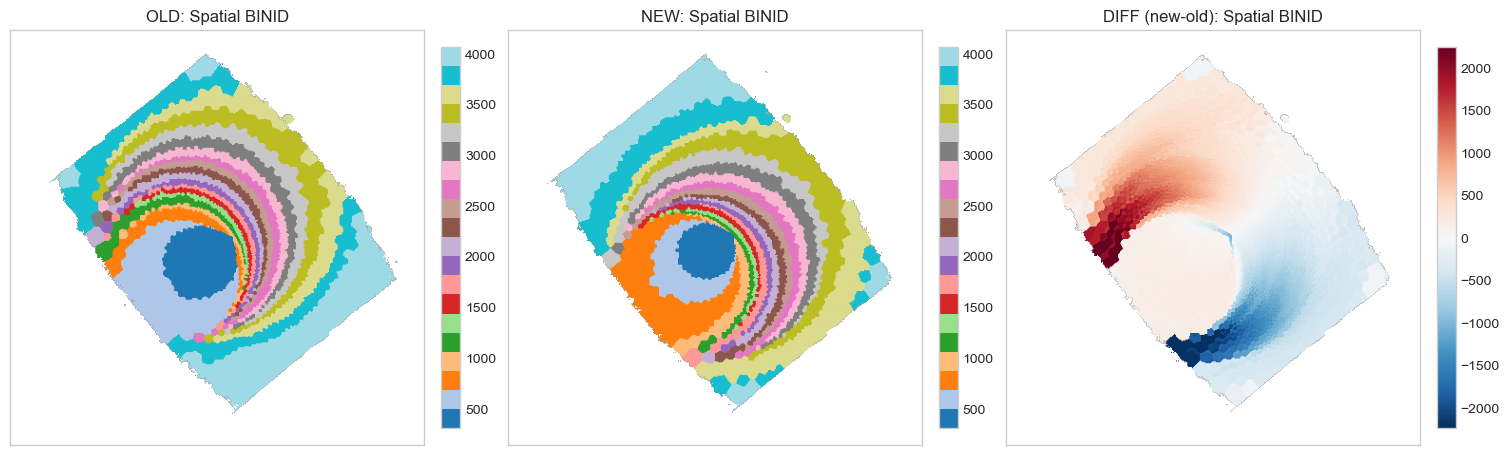

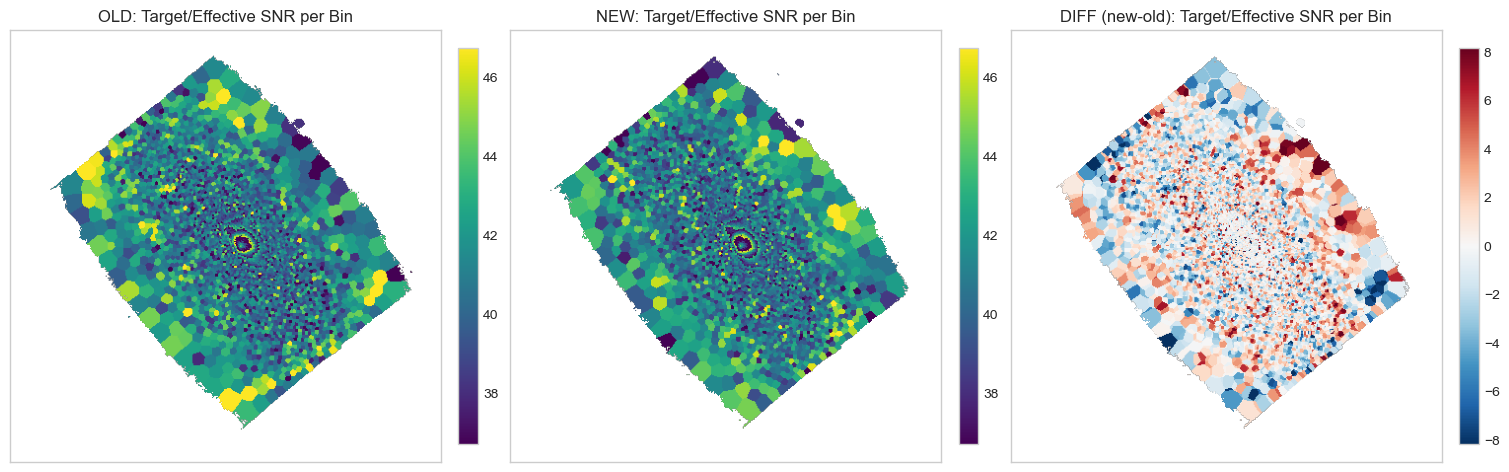

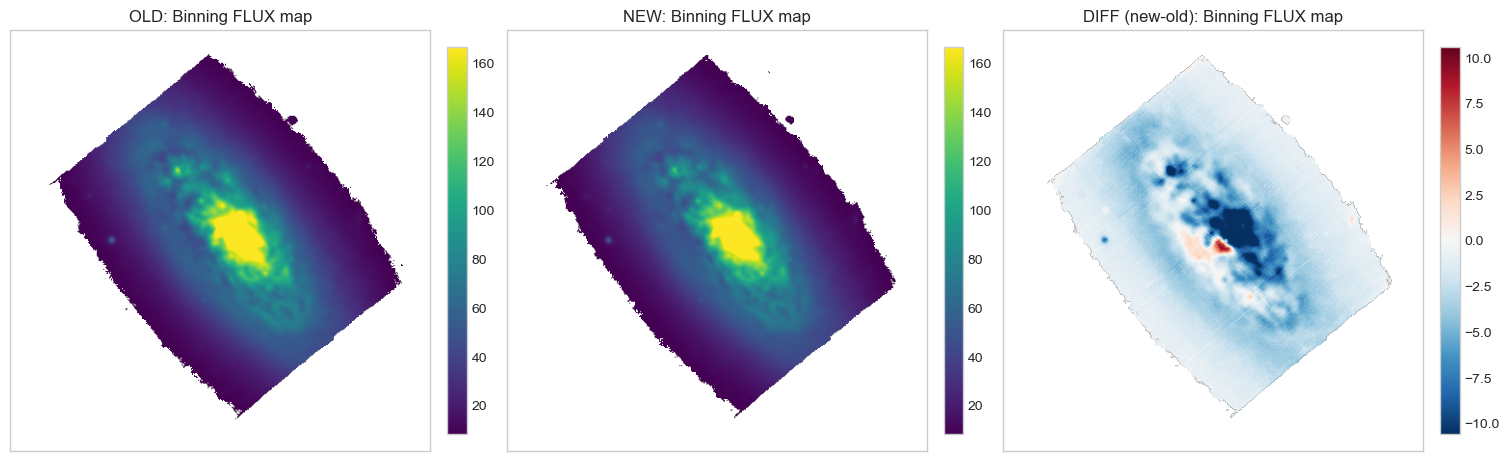

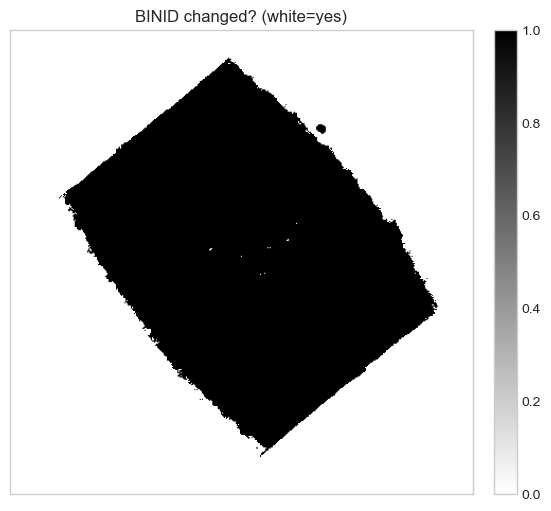

In [4]:
old_binid, new_binid = maps['spatial']['BINID']
valid_bin = np.isfinite(old_binid) & np.isfinite(new_binid)
same_bin = (old_binid == new_binid) & valid_bin

n_valid = valid_bin.sum()
frac_same = same_bin.sum() / n_valid if n_valid > 0 else np.nan

print(f'Valid spaxels with BINID in both runs: {n_valid}')
print(f'Fraction with identical BINID assignment: {frac_same:.4f}')
print(f'Unique bins old: {np.unique(old_binid[valid_bin]).size}')
print(f'Unique bins new: {np.unique(new_binid[valid_bin]).size}')

plot_triplet(old_binid, new_binid, 'Spatial BINID', cmap_main='tab20', cmap_diff='RdBu_r')
plot_triplet(*maps['spatial']['SNRBIN'], 'Target/Effective SNR per Bin')
plot_triplet(*maps['spatial']['FLUX'], 'Binning FLUX map')

# Binary mask of where bin assignment changed
changed = np.where(valid_bin, (old_binid != new_binid).astype(float), np.nan)
fig, ax = plt.subplots(1, 1, figsize=(6, 5), constrained_layout=True)
im = ax.imshow(changed, origin='lower', cmap='gray_r', vmin=0, vmax=1)
ax.set_title('BINID changed? (white=yes)')
ax.set_xticks([])
ax.set_yticks([])
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()

## Stellar Kinematics Comparison


### V


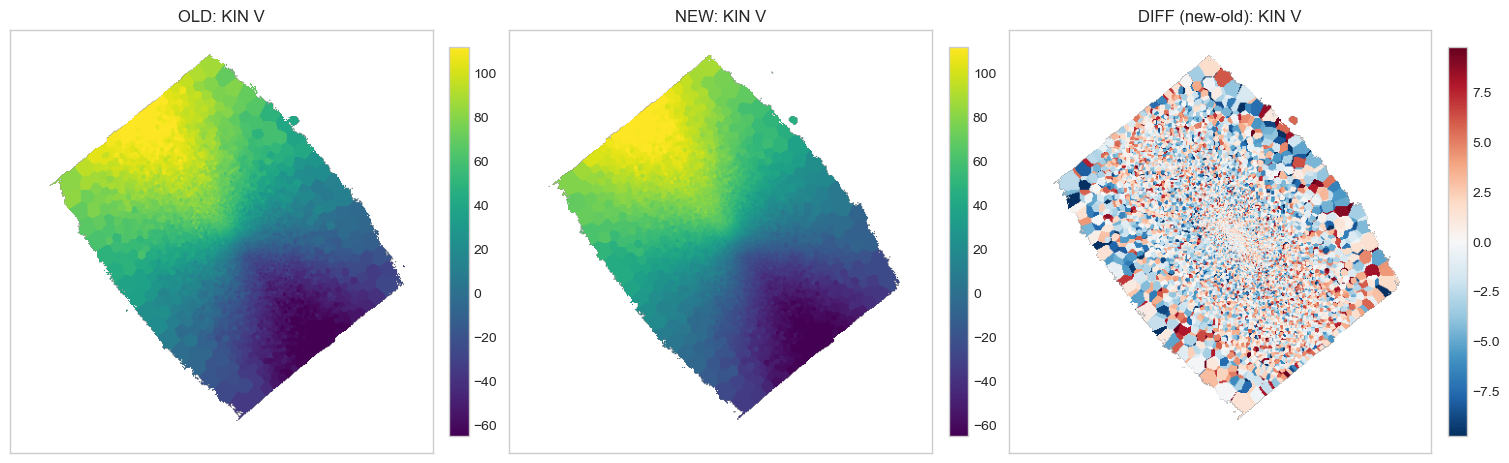

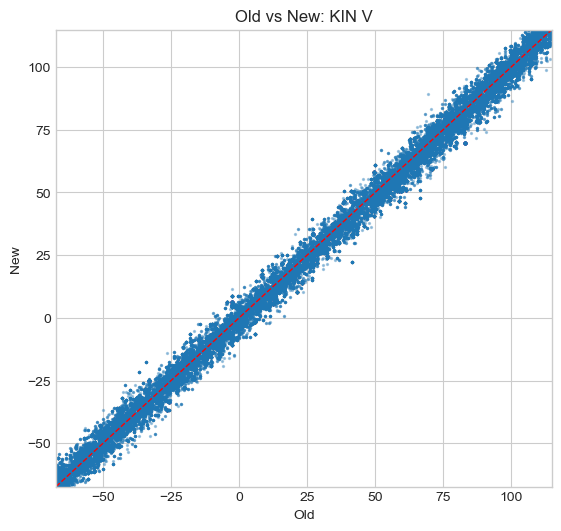


### SIGMA


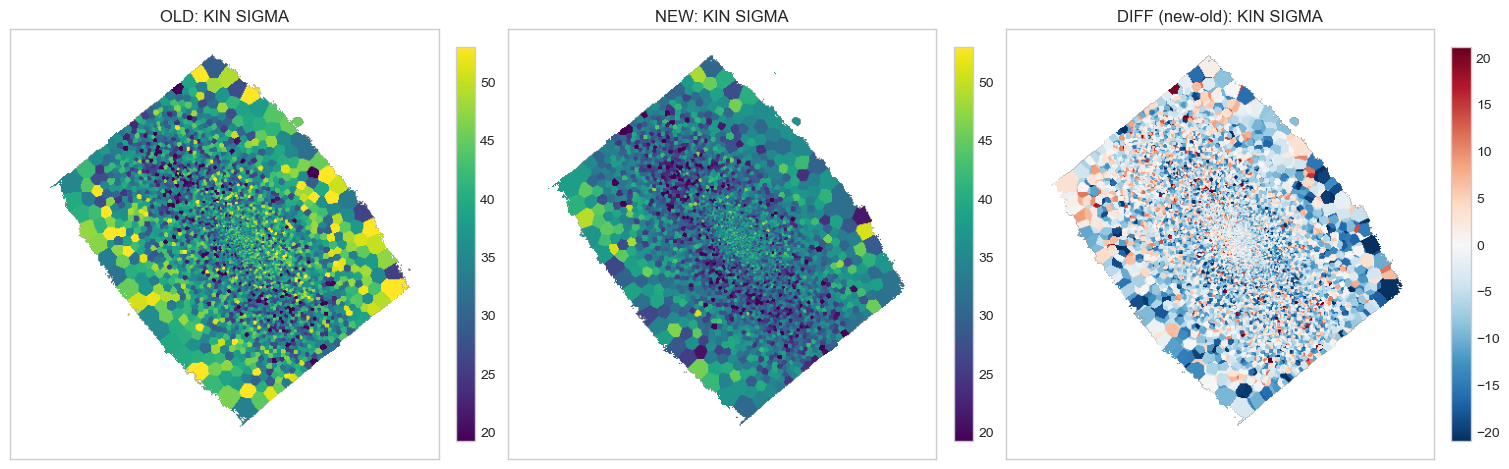

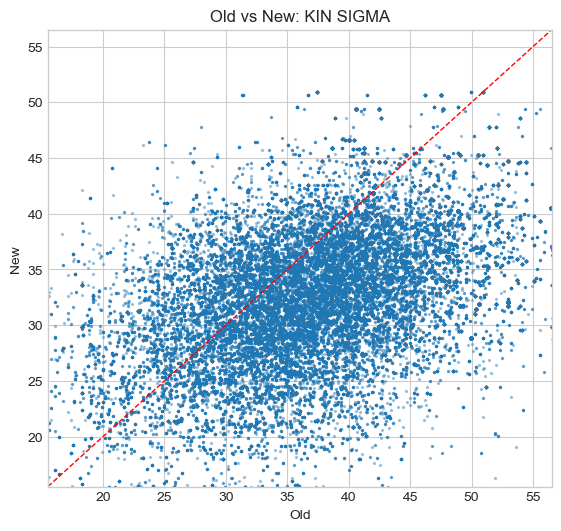


### H3


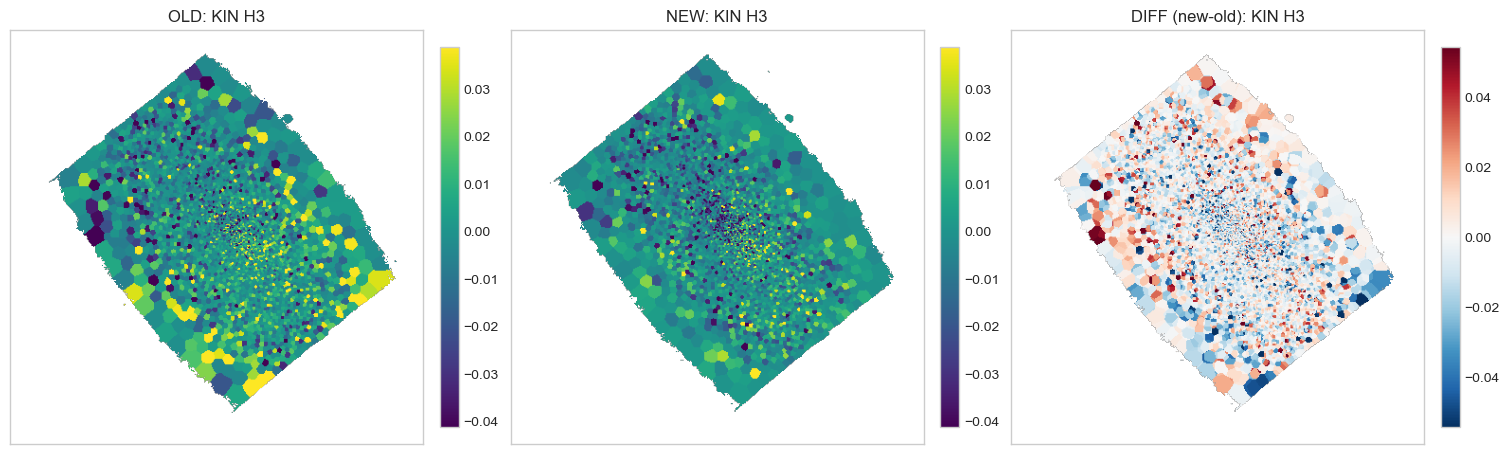

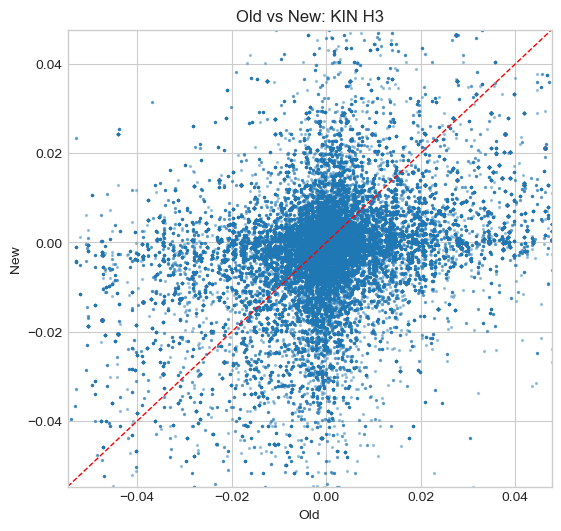


### H4


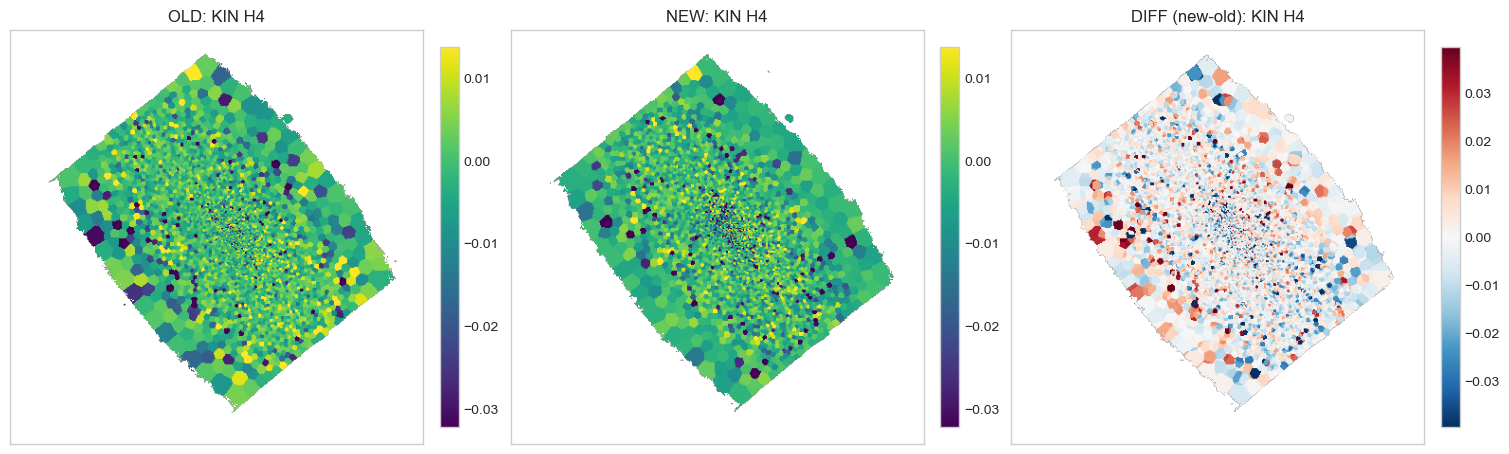

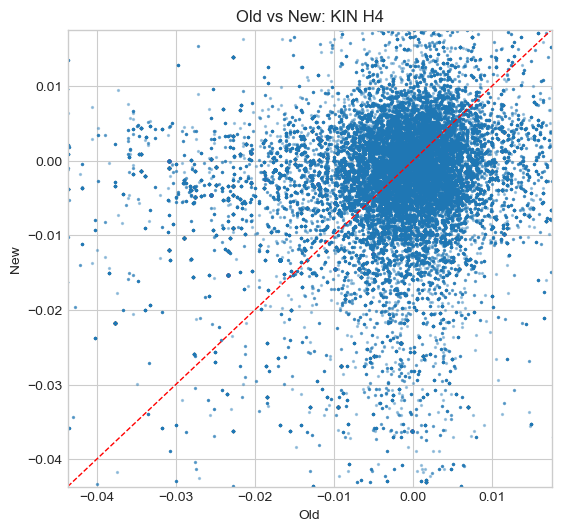

,quantity,n_valid,median_old,median_new,median_delta_new_minus_old,mean_delta_new_minus_old,std_delta,rms_delta,pearson_r
0,KIN_V,71225,26.625960,24.986251,-0.438611,-0.508725,4.073323,4.104967,0.996978
1,KIN_SIGMA,71225,37.643405,33.300784,-4.582509,-4.776749,7.925565,9.253751,0.486523
2,KIN_H3,71225,-0.000102,-0.000424,-0.001212,-0.002320,0.018812,0.018955,0.370594
3,KIN_H4,71225,-0.000931,-0.002038,-0.000882,-0.000807,0.013771,0.013795,0.202319


In [5]:
kin_stats = []
for q, (old_m, new_m) in maps['kin'].items():
    print(f'\n### {q}')
    plot_triplet(old_m, new_m, f'KIN {q}')
    scatter_old_new(old_m, new_m, f'KIN {q}')
    kin_stats.append(compare_stats(old_m, new_m, f'KIN_{q}'))

kin_stats_df = pd.DataFrame(kin_stats)
display(kin_stats_df)

## SFH Comparison (Age, Metallicity, E(B-V))


### AGE


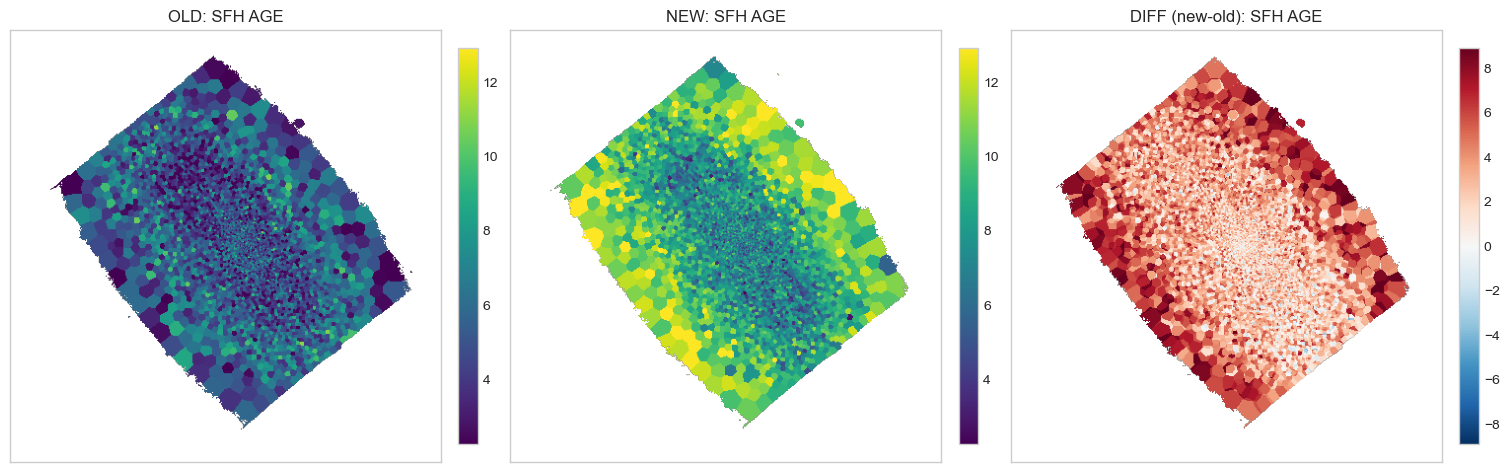

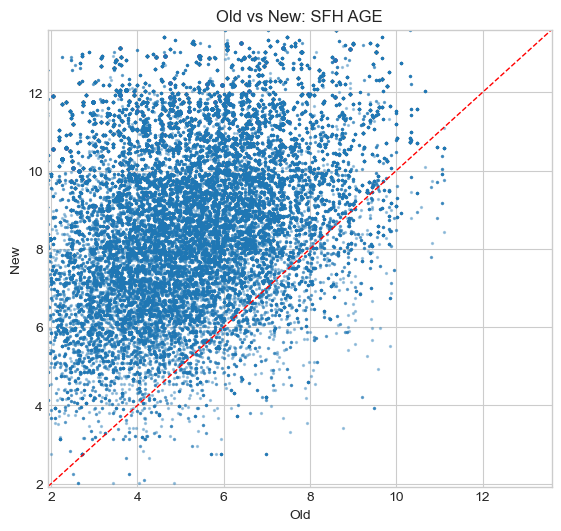


### METAL


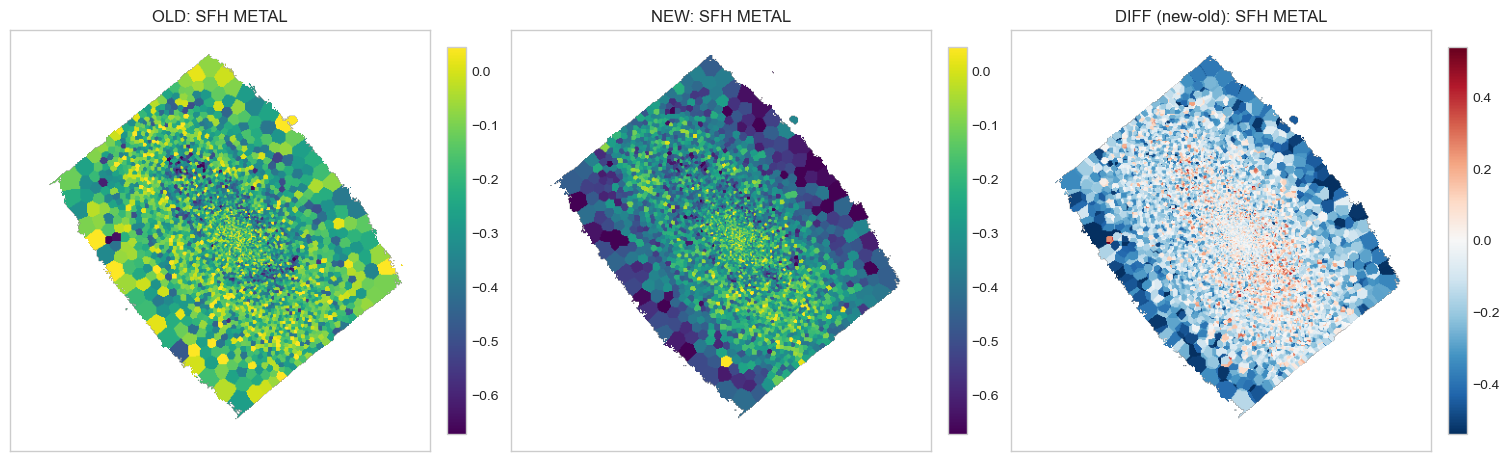

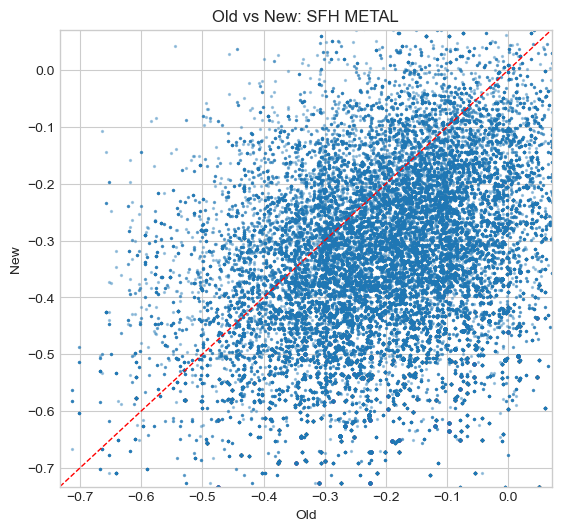


### EBV


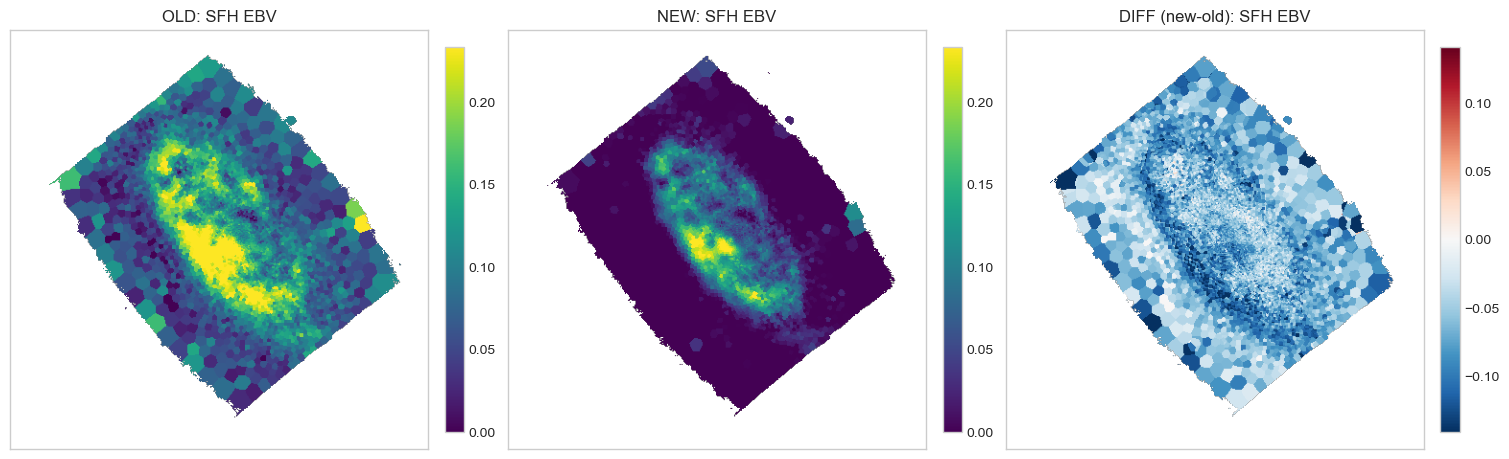

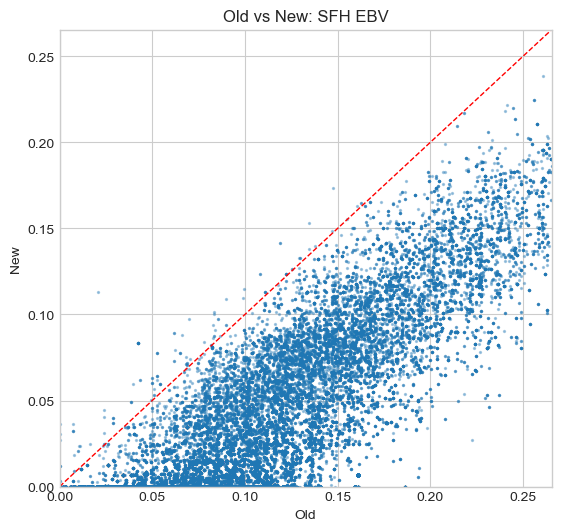

,quantity,n_valid,median_old,median_new,median_delta_new_minus_old,mean_delta_new_minus_old,std_delta,rms_delta,pearson_r
0,SFH_AGE,71225,5.204647,9.625292,4.177821,4.204053,2.376417,4.829225,0.290663
1,SFH_METAL,71225,-0.189988,-0.378534,-0.175175,-0.182747,0.185349,0.260290,0.286412
2,SFH_EBV,71225,0.082222,0.000000,-0.066295,-0.067904,0.031901,0.075024,0.851022


In [6]:
sfh_stats = []
for q, (old_m, new_m) in maps['sfh'].items():
    print(f'\n### {q}')
    plot_triplet(old_m, new_m, f'SFH {q}')
    scatter_old_new(old_m, new_m, f'SFH {q}')
    sfh_stats.append(compare_stats(old_m, new_m, f'SFH_{q}'))

sfh_stats_df = pd.DataFrame(sfh_stats)
display(sfh_stats_df)

## Combined Summary Table

In [7]:
spatial_stats = [
    compare_stats(*maps['spatial']['SNRBIN'], 'SPATIAL_SNRBIN'),
    compare_stats(*maps['spatial']['FLUX'], 'SPATIAL_FLUX'),
]

summary = pd.concat(
    [
        pd.DataFrame(spatial_stats),
        kin_stats_df,
        sfh_stats_df,
    ],
    ignore_index=True,
)

display(summary)

# Optional: save summary to disk for later report use
# summary.to_csv('IC3392_v3_vs_v3tk_summary_stats.csv', index=False)
# print('Saved: IC3392_v3_vs_v3tk_summary_stats.csv')

,quantity,n_valid,median_old,median_new,median_delta_new_minus_old,mean_delta_new_minus_old,std_delta,rms_delta,pearson_r
0,SPATIAL_SNRBIN,71225,41.379464,41.506123,-0.114812,-0.103436,3.139680,3.141384,0.115806
1,SPATIAL_FLUX,71225,36.942879,34.085298,-2.351901,-2.850011,2.520292,3.804528,0.999249
2,KIN_V,71225,26.625960,24.986251,-0.438611,-0.508725,4.073323,4.104967,0.996978
3,KIN_SIGMA,71225,37.643405,33.300784,-4.582509,-4.776749,7.925565,9.253751,0.486523
4,KIN_H3,71225,-0.000102,-0.000424,-0.001212,-0.002320,0.018812,0.018955,0.370594
5,KIN_H4,71225,-0.000931,-0.002038,-0.000882,-0.000807,0.013771,0.013795,0.202319
6,SFH_AGE,71225,5.204647,9.625292,4.177821,4.204053,2.376417,4.829225,0.290663
7,SFH_METAL,71225,-0.189988,-0.378534,-0.175175,-0.182747,0.185349,0.260290,0.286412
8,SFH_EBV,71225,0.082222,0.000000,-0.066295,-0.067904,0.031901,0.075024,0.851022
